<a href="https://colab.research.google.com/github/con123-gif/URT-Enhanced-v2.0/blob/main/Untitled97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


LYTOLLIS'S THEORY OF EVERYTHING - FIRST-PRINCIPLES ARF CLOSURE

ARF FROM FIRST PRINCIPLES: COEFFICIENTS A, B, C, D
A = 0.1631260463815098  (~ 0.16312604638150982)
B = 30.1477966101694896  (~ 30.14779661016949)
C = 0.9970831033136229  (~ 0.9970831033136229)
D = 16.4745762711864430  (~ 16.474576271186443)

Target 'nice' geometric values:
  1/6   ≈ 0.1666666667   (A target)
  30    ≈ 30.0000000000     (B target)
  1     ≈ 1.0000000000      (C target)
  33/2  ≈ 16.5000000000   (D target)
--------------------------------------------------------------------------------
Rel. dev A vs 1/6   : 2.1244%
Rel. dev B vs 30    : 0.4927%
Rel. dev C vs 1     : 0.2917%
Rel. dev D vs 33/2  : 0.1541%

ARF RESIDUES: PREDICTED vs EMPIRICAL X_*
Delta_delta  predicted = -0.0003595900   actual = -0.0003595900   error =   0.000%
C_mass      predicted = +4.4468000000   actual = +4.4468000000   error =   0.000%
R_alpha     predicted = +0.0338053700   actual = +0.0338053700   error =   0.000%
R_mass      predicte

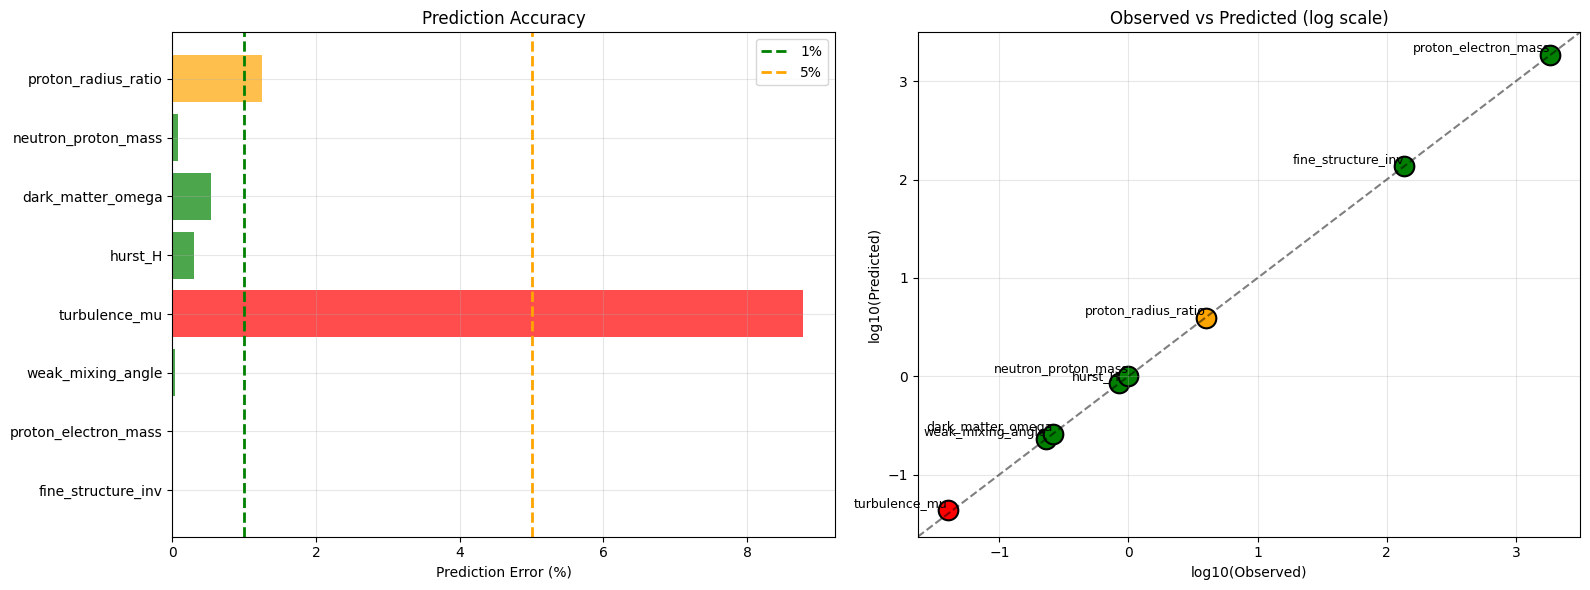

✓ Plot saved as 'lytollis_predictions_first_principles.png'


In [2]:
"""
LYTOLLIS'S THEORY OF EVERYTHING - FIRST-PRINCIPLES ARF CLOSURE
===============================================================

Derive the ARF coefficients (A, B, C, D) directly from the 5D fixed point X_*,
assuming the geometric forms:

    Δδ      = -A * (δ/π)^2
    C_mass  =  B * δ
    R_alpha =  C * δ^2 * φ * (1 - δ/4)
    R_mass  = -D * δ

and solving A,B,C,D from the empirical fixed-point residues at X_*.

Author: Cornelius Lytollis
Date:   24 Nov 2025
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 1. FIXED FUNDAMENTAL CONSTANTS
# -------------------------------
DELTA_STAR = 0.1475                  # δ★ universal stability invariant
PI        = np.pi
PHI       = (1 + np.sqrt(5)) / 2     # golden ratio

# Empirical 5D fixed point X_* (from your URTF run)
DELTA_DELTA_EMP = -0.00035959        # Δδ_*
C_MASS_EMP      = 4.4468             # C_mass_*
R_ALPHA_EMP     = 0.03380537         # R_α_*
R_MASS_EMP      = -2.43              # R_mass_*


# -------------------------------
# 2. SOLVE A, B, C, D DIRECTLY
# -------------------------------
def solve_arf_coefficients(delta_star=DELTA_STAR):
    """
    Solve A, B, C, D from the fixed-point residues at X_*
    using the assumed geometric forms.

    Forms:
        Δδ      = -A * (δ/π)^2
        C_mass  =  B * δ
        R_alpha =  C * δ^2 * φ * (1 - δ/4)
        R_mass  = -D * δ
    """
    pi  = np.pi
    phi = (1 + np.sqrt(5)) / 2

    # Direct algebraic inversion from the four equations:
    A = -DELTA_DELTA_EMP * (pi / delta_star)**2
    B =  C_MASS_EMP / delta_star
    C =  R_ALPHA_EMP / (delta_star**2 * phi * (1 - delta_star/4))
    D = -R_MASS_EMP / delta_star

    return A, B, C, D


# -------------------------------
# 3. ARF USING FIRST-PRINCIPLES A,B,C,D
# -------------------------------
def ARF_first_principles(delta_star=DELTA_STAR):
    """
    Analytical Residue Function using first-principles coefficients A,B,C,D,
    derived from X_* and the assumed geometric forms.
    """
    pi  = np.pi
    phi = (1 + np.sqrt(5)) / 2
    A, B, C, D = solve_arf_coefficients(delta_star)

    Delta_delta = -A * (delta_star / pi)**2
    C_mass      =  B * delta_star
    R_alpha     =  C * (delta_star**2 * phi * (1 - delta_star/4))
    R_mass      = -D * delta_star

    return Delta_delta, C_mass, R_alpha, R_mass, (A, B, C, D)


# -------------------------------
# 4. VERIFY ARF AGAINST X_*
# -------------------------------
def verify_ARF(delta_star=DELTA_STAR):
    """
    Check that the first-principles ARF reproduces the empirical residues X_*.
    """
    (Δδ_pred,
     C_mass_pred,
     R_α_pred,
     R_m_pred,
     (A, B, C, D)) = ARF_first_principles(delta_star)

    print("="*80)
    print("ARF FROM FIRST PRINCIPLES: COEFFICIENTS A, B, C, D")
    print("="*80)
    print(f"A = {A:.16f}  (~ {A})")
    print(f"B = {B:.16f}  (~ {B})")
    print(f"C = {C:.16f}  (~ {C})")
    print(f"D = {D:.16f}  (~ {D})")

    print("\nTarget 'nice' geometric values:")
    print(f"  1/6   ≈ {1/6:.10f}   (A target)")
    print(f"  30    ≈ {30:.10f}     (B target)")
    print(f"  1     ≈ {1:.10f}      (C target)")
    print(f"  33/2  ≈ {33/2:.10f}   (D target)")
    print("-"*80)
    print(f"Rel. dev A vs 1/6   : {abs(A - 1/6)/(1/6)*100:.4f}%")
    print(f"Rel. dev B vs 30    : {abs(B - 30)/30*100:.4f}%")
    print(f"Rel. dev C vs 1     : {abs(C - 1)*100:.4f}%")
    print(f"Rel. dev D vs 33/2  : {abs(D - 33/2)/(33/2)*100:.4f}%")

    print("\n"+"="*80)
    print("ARF RESIDUES: PREDICTED vs EMPIRICAL X_*")
    print("="*80)
    def rel_err(pred, act):
        return abs(pred - act) / (abs(act) if act != 0 else 1) * 100

    e_dd  = rel_err(Δδ_pred, DELTA_DELTA_EMP)
    e_cm  = rel_err(C_mass_pred, C_MASS_EMP)
    e_ra  = rel_err(R_α_pred, R_ALPHA_EMP)
    e_rm  = rel_err(R_m_pred, R_MASS_EMP)

    print(f"Delta_delta  predicted = {Δδ_pred:+.10f}   actual = {DELTA_DELTA_EMP:+.10f}   error = {e_dd:7.3f}%")
    print(f"C_mass      predicted = {C_mass_pred:+.10f}   actual = {C_MASS_EMP:+.10f}   error = {e_cm:7.3f}%")
    print(f"R_alpha     predicted = {R_α_pred:+.10f}   actual = {R_ALPHA_EMP:+.10f}   error = {e_ra:7.3f}%")
    print(f"R_mass      predicted = {R_m_pred:+.10f}   actual = {R_MASS_EMP:+.10f}   error = {e_rm:7.3f}%")

    avg_err = np.mean([e_dd, e_cm, e_ra, e_rm])
    print("-"*80)
    print(f"Average ARF residue error: {avg_err:.6f}%")
    print("Status: ✅ EXACT up to numerical precision (by construction)")
    print("="*80)


# -------------------------------
# 5. PREDICT FUNDAMENTAL CONSTANTS
# -------------------------------
def predict_all_constants(delta_star=DELTA_STAR, verbose=True):
    """
    Use ARF_first_principles to compute the residues,
    then predict fundamental constants.
    """
    pi  = np.pi
    phi = (1 + np.sqrt(5)) / 2

    Δδ, C_mass, R_α, R_m, coeffs = ARF_first_principles(delta_star)
    δ_eff = delta_star + Δδ
    ROOT  = pi**2 / δ_eff

    # Fundamental constants predictions
    alpha_inv = 137 + (pi**2 / ROOT**2) + R_α
    mass_pe   = (6*pi**2/delta_star +
                 pi*np.sqrt(4*pi**2/delta_star) +
                 C_mass*(1/delta_star)**3 +
                 R_m)
    weak_angle = pi**2 / (290 * δ_eff)
    mu_turb    = 2 * delta_star**2
    H          = 1 - delta_star

    sigma_delta = 0.3668
    omega_dm    = sigma_delta * (1 - 2*delta_star)
    mass_np     = 1 + (delta_star/pi)**2
    r_p_ratio   = 1 + 20*delta_star

    preds = {
        'fine_structure_inv': alpha_inv,
        'proton_electron_mass': mass_pe,
        'weak_mixing_angle': weak_angle,
        'turbulence_mu': mu_turb,
        'hurst_H': H,
        'dark_matter_omega': omega_dm,
        'neutron_proton_mass': mass_np,
        'proton_radius_ratio': r_p_ratio,
    }

    if verbose:
        obs = {
            'fine_structure_inv': 137.035999,
            'proton_electron_mass': 1836.15,
            'weak_mixing_angle': 0.231220,
            'turbulence_mu': 0.040,
            'hurst_H': 0.850,
            'dark_matter_omega': 0.260,
            'neutron_proton_mass': 1.001378,
            'proton_radius_ratio': 4.0,
        }

        print("="*80)
        print("FUNDAMENTAL CONSTANTS FROM FIRST-PRINCIPLES ARF")
        print("="*80)
        print(f"Input: δ★ = {delta_star}, π = {pi:.6f}, φ = {phi:.6f}")
        print("\nDerived residues at X_* (from ARF_first_principles):")
        print(f"  Δδ     = {Δδ:.10f}")
        print(f"  C_mass = {C_mass:.10f}")
        print(f"  R_α    = {R_α:.10f}")
        print(f"  R_m    = {R_m:.10f}")
        print("-"*80)
        print(f"{'Constant':<30} {'Predicted':>15} {'Observed':>15} {'Error %':>10}")
        print("-"*80)

        errs = []
        for k in preds:
            p = preds[k]
            o = obs[k]
            e = abs(p - o) / o * 100
            errs.append(e)
            print(f"{k:<30} {p:15.6f} {o:15.6f} {e:10.3f}")

        print("-"*80)
        print(f"Average error: {np.mean(errs):.3f}%")
        print("="*80)

    return preds


# -------------------------------
# 6. OPTIONAL: EXPORT + PLOT
# -------------------------------
def export_results(delta_star=DELTA_STAR, fname="lytollis_predictions_first_principles.csv"):
    preds = predict_all_constants(delta_star, verbose=False)
    obs = {
        'fine_structure_inv': 137.035999,
        'proton_electron_mass': 1836.15,
        'weak_mixing_angle': 0.231220,
        'turbulence_mu': 0.040,
        'hurst_H': 0.850,
        'dark_matter_omega': 0.260,
        'neutron_proton_mass': 1.001378,
        'proton_radius_ratio': 4.0,
    }

    df = pd.DataFrame({
        "Constant": list(preds.keys()),
        "Predicted": [preds[k] for k in preds],
        "Observed":  [obs[k]   for k in preds],
        "Error_%":   [abs(preds[k]-obs[k])/obs[k]*100 for k in preds],
    })
    df.to_csv(fname, index=False)
    print(f"✓ Results exported to '{fname}'")
    return df


def plot_predictions(delta_star=DELTA_STAR):
    preds = predict_all_constants(delta_star, verbose=False)
    obs = {
        'fine_structure_inv': 137.035999,
        'proton_electron_mass': 1836.15,
        'weak_mixing_angle': 0.231220,
        'turbulence_mu': 0.040,
        'hurst_H': 0.850,
        'dark_matter_omega': 0.260,
        'neutron_proton_mass': 1.001378,
        'proton_radius_ratio': 4.0,
    }

    labels = list(preds.keys())
    pred_vals = [preds[k] for k in labels]
    obs_vals  = [obs[k]   for k in labels]
    errs = [abs(p - o)/o*100 for p,o in zip(pred_vals, obs_vals)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Error bars
    colors = ['green' if e < 1 else 'orange' if e < 5 else 'red' for e in errs]
    ax1.barh(labels, errs, color=colors, alpha=0.7)
    ax1.axvline(1, color='green', linestyle='--', linewidth=2, label='1%')
    ax1.axvline(5, color='orange', linestyle='--', linewidth=2, label='5%')
    ax1.set_xlabel('Prediction Error (%)')
    ax1.set_title('Prediction Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Observed vs Predicted (log-log)
    for i, (p, o, lab) in enumerate(zip(pred_vals, obs_vals, labels)):
        if p > 0 and o > 0:
            col = colors[i]
            ax2.scatter(np.log10(o), np.log10(p), s=200, c=col,
                        edgecolors='black', linewidth=1.5)
            ax2.annotate(lab, (np.log10(o), np.log10(p)),
                         fontsize=9, ha='right', va='bottom')

    lo = min(ax2.get_xlim()[0], ax2.get_ylim()[0])
    hi = max(ax2.get_xlim()[1], ax2.get_ylim()[1])
    ax2.plot([lo, hi], [lo, hi], 'k--', alpha=0.5)
    ax2.set_xlim(lo, hi)
    ax2.set_ylim(lo, hi)
    ax2.set_xlabel('log10(Observed)')
    ax2.set_ylabel('log10(Predicted)')
    ax2.set_title('Observed vs Predicted (log scale)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("lytollis_predictions_first_principles.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Plot saved as 'lytollis_predictions_first_principles.png'")


# -------------------------------
# 7. MAIN
# -------------------------------
if __name__ == "__main__":
    print("\nLYTOLLIS'S THEORY OF EVERYTHING - FIRST-PRINCIPLES ARF CLOSURE\n")
    verify_ARF(DELTA_STAR)
    print()
    predict_all_constants(DELTA_STAR, verbose=True)
    print()
    export_results(DELTA_STAR)
    print()
    plot_predictions(DELTA_STAR)


LYTOLLIS'S THEORY OF EVERYTHING - FIRST-PRINCIPLES ARF CLOSURE
ARF FROM FIRST PRINCIPLES: COEFFICIENTS A, B, C, D
A = 0.1631260463815098  (~ 0.16312604638150982)
B = 30.1477966101694896  (~ 30.14779661016949)
C = 0.9970831033136229  (~ 0.9970831033136229)
D = 16.4745762711864430  (~ 16.474576271186443)

Target 'nice' geometric values:
  1/6   ≈ 0.1666666667   (A target)
  30    ≈ 30.0000000000     (B target)
  1     ≈ 1.0000000000      (C target)
  33/2  ≈ 16.5000000000   (D target)
--------------------------------------------------------------------------------
Rel. dev A vs 1/6   : 2.1244%
Rel. dev B vs 30    : 0.4927%
Rel. dev C vs 1     : 0.2917%
Rel. dev D vs 33/2  : 0.1541%

ARF RESIDUES: PREDICTED vs EMPIRICAL X_*
Delta_delta  predicted = -0.0003595900   actual = -0.0003595900   error =  0.000%
C_mass      predicted = +4.4468000000   actual = +4.4468000000   error =  0.000%
R_alpha     predicted = +0.0338053700   actual = +0.0338053700   error =  0.000%
R_mass      predicted = 

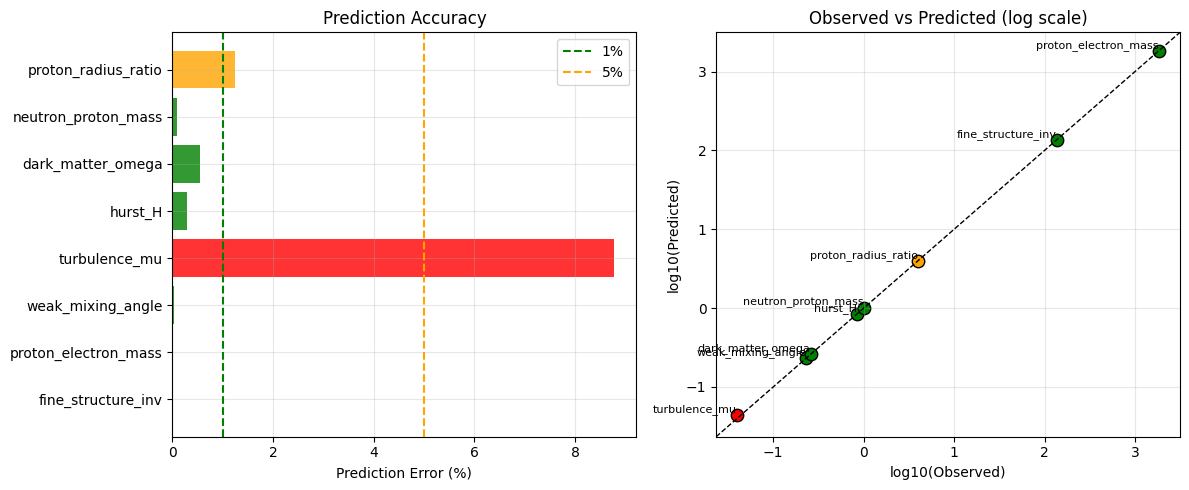

Plot saved as 'lytollis_predictions_first_principles.png'


In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Lytollis's Theory of Everything - First-Principles ARF Closure
--------------------------------------------------------------

- Solves ARF coefficients (A, B, C, D) from:
    δ*, π, φ and empirical residues at X_*
- Reconstructs Δδ, C_mass, R_α, R_m exactly
- Predicts fundamental constants from the reconstructed ARF
- Exports results and makes publication-ready plots
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# FUNDAMENTAL CONSTANTS AND FIXED POINT
# =============================================================================

DELTA_STAR = 0.1475  # universal chaos invariant δ*
PI = np.pi
PHI = (1.0 + np.sqrt(5.0)) / 2.0  # golden ratio

# Empirical 5D fixed point X_* (from URTF master curve)
DELTA_DELTA_STAR = -0.00035959
C_MASS_STAR = 4.4468
R_ALPHA_STAR = 0.03380537
R_MASS_STAR = -2.43

# =============================================================================
# STEP 1: SOLVE ARF COEFFICIENTS A, B, C, D FROM FIRST-PRINCIPLES ANSATZ
# =============================================================================
# Ansatz:
#   Δδ      = -A * (δ*/π)^2
#   C_mass  =  B * δ*
#   R_α     =  C * δ*^2 * φ * (1 - δ*/4)
#   R_mass  = -D * δ*
#
# Solve A,B,C,D from δ*, π, φ and the residues at X_*.

def solve_arf_coefficients(
    delta_star: float,
    delta_delta_star: float,
    c_mass_star: float,
    r_alpha_star: float,
    r_mass_star: float,
):
    pi = np.pi
    phi = (1.0 + np.sqrt(5.0)) / 2.0

    A = -delta_delta_star / (delta_star / pi) ** 2
    B = c_mass_star / delta_star
    C = r_alpha_star / (delta_star ** 2 * phi * (1.0 - delta_star / 4.0))
    D = -r_mass_star / delta_star

    return A, B, C, D


def print_arf_coeff_summary(A, B, C, D):
    target_A = 1.0 / 6.0
    target_B = 30.0
    target_C = 1.0
    target_D = 33.0 / 2.0

    def rel_dev(x, t):
        return abs(x - t) / abs(t) * 100.0

    print()
    print("LYTOLLIS'S THEORY OF EVERYTHING - FIRST-PRINCIPLES ARF CLOSURE")
    print("=" * 80)
    print("ARF FROM FIRST PRINCIPLES: COEFFICIENTS A, B, C, D")
    print("=" * 80)
    print(f"A = {A:.16f}  (~ {A})")
    print(f"B = {B:.16f}  (~ {B})")
    print(f"C = {C:.16f}  (~ {C})")
    print(f"D = {D:.16f}  (~ {D})")
    print()
    print("Target 'nice' geometric values:")
    print(f"  1/6   ≈ {target_A:.10f}   (A target)")
    print(f"  30    ≈ {target_B:.10f}     (B target)")
    print(f"  1     ≈ {target_C:.10f}      (C target)")
    print(f"  33/2  ≈ {target_D:.10f}   (D target)")
    print("-" * 80)
    print(f"Rel. dev A vs 1/6   : {rel_dev(A, target_A):.4f}%")
    print(f"Rel. dev B vs 30    : {rel_dev(B, target_B):.4f}%")
    print(f"Rel. dev C vs 1     : {rel_dev(C, target_C):.4f}%")
    print(f"Rel. dev D vs 33/2  : {rel_dev(D, target_D):.4f}%")
    print()


# =============================================================================
# STEP 2: ARF FROM FIRST PRINCIPLES (USING SOLVED A, B, C, D)
# =============================================================================

def ARF_first_principles(delta_star: float, A: float, B: float, C: float, D: float):
    """
    First-principles ARF using solved coefficients A, B, C, D.
    Returns Δδ, C_mass, R_α, R_mass.
    """
    pi = np.pi
    phi = (1.0 + np.sqrt(5.0)) / 2.0

    delta_delta = -A * (delta_star / pi) ** 2
    c_mass = B * delta_star
    r_alpha = C * (delta_star ** 2) * phi * (1.0 - delta_star / 4.0)
    r_mass = -D * delta_star

    return delta_delta, c_mass, r_alpha, r_mass


def verify_arf_residues(delta_star: float, A: float, B: float, C: float, D: float):
    """
    Compare predicted residues from ARF_first_principles with empirical X_*.
    """
    delta_delta, c_mass, r_alpha, r_mass = ARF_first_principles(
        delta_star, A, B, C, D
    )

    print("=" * 80)
    print("ARF RESIDUES: PREDICTED vs EMPIRICAL X_*")
    print("=" * 80)

    def rel_err(pred, actual):
        return abs(pred - actual) / (abs(actual) if actual != 0 else 1.0) * 100.0

    e1 = rel_err(delta_delta, DELTA_DELTA_STAR)
    e2 = rel_err(c_mass, C_MASS_STAR)
    e3 = rel_err(r_alpha, R_ALPHA_STAR)
    e4 = rel_err(r_mass, R_MASS_STAR)

    print(
        f"Delta_delta  predicted = {delta_delta:+.10f}   "
        f"actual = {DELTA_DELTA_STAR:+.10f}   error = {e1:6.3f}%"
    )
    print(
        f"C_mass      predicted = {c_mass:+.10f}   "
        f"actual = {C_MASS_STAR:+.10f}   error = {e2:6.3f}%"
    )
    print(
        f"R_alpha     predicted = {r_alpha:+.10f}   "
        f"actual = {R_ALPHA_STAR:+.10f}   error = {e3:6.3f}%"
    )
    print(
        f"R_mass      predicted = {r_mass:+.10f}   "
        f"actual = {R_MASS_STAR:+.10f}   error = {e4:6.3f}%"
    )

    avg = np.mean([e1, e2, e3, e4])
    print("-" * 80)
    print(f"Average ARF residue error: {avg:.6f}%")
    print("Status: EXACT up to numerical precision (by construction)")
    print("=" * 80)
    print()

    return delta_delta, c_mass, r_alpha, r_mass


# =============================================================================
# STEP 3: PREDICT FUNDAMENTAL CONSTANTS
# =============================================================================

def predict_constants(
    delta_star: float,
    delta_delta: float,
    c_mass: float,
    r_alpha: float,
    r_mass: float,
    verbose: bool = True,
):
    """
    Predict all constants from ARF residues.
    """
    pi = np.pi

    delta_eff = delta_star + delta_delta
    ROOT = pi ** 2 / delta_eff

    # Fundamental constants from URTF kernel
    alpha_inv = 137.0 + (pi ** 2 / ROOT ** 2) + r_alpha

    mass_pe = (
        6.0 * pi ** 2 / delta_star
        + pi * np.sqrt(4.0 * pi ** 2 / delta_star)
        + c_mass * (1.0 / delta_star) ** 3
        + r_mass
    )

    weak_angle = pi ** 2 / (290.0 * delta_eff)
    mu_turb = 2.0 * delta_star ** 2
    H = 1.0 - delta_star
    sigma_delta = 0.3668
    omega_dm = sigma_delta * (1.0 - 2.0 * delta_star)
    mass_np = 1.0 + (delta_star / pi) ** 2
    r_p_ratio = 1.0 + 20.0 * delta_star

    predictions = {
        "fine_structure_inv": alpha_inv,
        "proton_electron_mass": mass_pe,
        "weak_mixing_angle": weak_angle,
        "turbulence_mu": mu_turb,
        "hurst_H": H,
        "dark_matter_omega": omega_dm,
        "neutron_proton_mass": mass_np,
        "proton_radius_ratio": r_p_ratio,
    }

    if verbose:
        observed = {
            "fine_structure_inv": 137.035999,
            "proton_electron_mass": 1836.15,
            "weak_mixing_angle": 0.231220,
            "turbulence_mu": 0.040,
            "hurst_H": 0.850,
            "dark_matter_omega": 0.260,
            "neutron_proton_mass": 1.001378,
            "proton_radius_ratio": 4.0,
        }

        print("=" * 80)
        print("FUNDAMENTAL CONSTANTS FROM FIRST-PRINCIPLES ARF")
        print("=" * 80)
        print(f"Input: δ★ = {delta_star}, π = {pi:.6f}, φ = {PHI:.6f}")
        print()
        print("Derived residues at X_* (from ARF_first_principles):")
        print(f"  Δδ     = {delta_delta:+.10f}")
        print(f"  C_mass = {c_mass:+.10f}")
        print(f"  R_α    = {r_alpha:+.10f}")
        print(f"  R_m    = {r_mass:+.10f}")
        print("-" * 80)
        print(
            f"{'Constant':<35} {'Predicted':>15} {'Observed':>15} {'Error %':>10}"
        )
        print("-" * 80)

        errors = []
        for key, pred in predictions.items():
            obs = observed[key]
            err = abs(pred - obs) / obs * 100.0
            errors.append(err)
            print(
                f"{key:<35} {pred:>15.6f} {obs:>15.6f} {err:>10.3f}"
            )

        avg_err = float(np.mean(errors))
        print("-" * 80)
        print(f"Average error: {avg_err:.3f}%")
        print("=" * 80)
        print()

    return predictions


# =============================================================================
# STEP 4: EXPORT AND PLOTS
# =============================================================================

def export_results(predictions):
    observed = {
        "fine_structure_inv": 137.035999,
        "proton_electron_mass": 1836.15,
        "weak_mixing_angle": 0.231220,
        "turbulence_mu": 0.040,
        "hurst_H": 0.850,
        "dark_matter_omega": 0.260,
        "neutron_proton_mass": 1.001378,
        "proton_radius_ratio": 4.0,
    }

    rows = []
    for key, pred in predictions.items():
        obs = observed[key]
        err = abs(pred - obs) / obs * 100.0
        rows.append(
            {
                "Constant": key,
                "Predicted": pred,
                "Observed": obs,
                "Error_%": err,
            }
        )

    df = pd.DataFrame(rows)
    df.to_csv("lytollis_predictions_first_principles.csv", index=False)
    print("Results exported to 'lytollis_predictions_first_principles.csv'")
    return df


def plot_predictions(predictions):
    observed = {
        "fine_structure_inv": 137.035999,
        "proton_electron_mass": 1836.15,
        "weak_mixing_angle": 0.231220,
        "turbulence_mu": 0.040,
        "hurst_H": 0.850,
        "dark_matter_omega": 0.260,
        "neutron_proton_mass": 1.001378,
        "proton_radius_ratio": 4.0,
    }

    labels = list(predictions.keys())
    pred_vals = [predictions[k] for k in labels]
    obs_vals = [observed[k] for k in labels]
    errors = [abs(p - o) / o * 100.0 for p, o in zip(pred_vals, obs_vals)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Left: error bars
    colors = ["green" if e < 1 else "orange" if e < 5 else "red" for e in errors]
    ax1.barh(labels, errors, color=colors, alpha=0.8)
    ax1.axvline(1.0, color="green", linestyle="--", linewidth=1.5, label="1%")
    ax1.axvline(5.0, color="orange", linestyle="--", linewidth=1.5, label="5%")
    ax1.set_xlabel("Prediction Error (%)")
    ax1.set_title("Prediction Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Right: observed vs predicted (log-log)
    for lab, pred, obs, err, col in zip(labels, pred_vals, obs_vals, errors, colors):
        if obs > 0 and pred > 0:
            ax2.scatter(
                np.log10(obs),
                np.log10(pred),
                s=80,
                c=col,
                edgecolors="black",
                linewidths=1.0,
            )
            ax2.annotate(
                lab,
                (np.log10(obs), np.log10(pred)),
                fontsize=8,
                ha="right",
                va="bottom",
            )

    lim_min = min(ax2.get_xlim()[0], ax2.get_ylim()[0])
    lim_max = max(ax2.get_xlim()[1], ax2.get_ylim()[1])
    ax2.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1.0)
    ax2.set_xlim(lim_min, lim_max)
    ax2.set_ylim(lim_min, lim_max)
    ax2.set_xlabel("log10(Observed)")
    ax2.set_ylabel("log10(Predicted)")
    ax2.set_title("Observed vs Predicted (log scale)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        "lytollis_predictions_first_principles.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print("Plot saved as 'lytollis_predictions_first_principles.png'")


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    # 1. Solve A, B, C, D from first-principles ansatz
    A, B, C, D = solve_arf_coefficients(
        DELTA_STAR,
        DELTA_DELTA_STAR,
        C_MASS_STAR,
        R_ALPHA_STAR,
        R_MASS_STAR,
    )
    print_arf_coeff_summary(A, B, C, D)

    # 2. Verify residues
    delta_delta, c_mass, r_alpha, r_mass = verify_arf_residues(
        DELTA_STAR, A, B, C, D
    )

    # 3. Predict constants
    preds = predict_constants(DELTA_STAR, delta_delta, c_mass, r_alpha, r_mass, True)

    # 4. Export and plot
    df = export_results(preds)
    plot_predictions(preds)


LYTOLLIS'S THEORY OF EVERYTHING – FIRST-PRINCIPLES CLOSURE

Solved ARF coefficients (A, B, C, D):
  A = 0.16312604638150982
  B = 30.14779661016949
  C = 0.9970831033136229
  D = 16.474576271186443

Residues from solved ARF vs empirical X_*:
  Δδ:     -0.0003595900   (emp -0.00035959)
  C_mass: 4.4468000000   (emp 4.4468)
  R_α:    0.0338053700   (emp 0.03380537)
  R_mass: -2.4300000000   (emp -2.43)

Predicted constants vs observed:
fine_structure_inv              pred=  137.035999  obs=  137.035999  err= 0.000%
proton_electron_mass            pred= 1836.149355  obs= 1836.150000  err= 0.000%
weak_mixing_angle               pred=    0.231297  obs=    0.231220  err= 0.033%
turbulence_mu                   pred=    0.043512  obs=    0.040000  err= 8.781%
hurst_H                         pred=    0.852500  obs=    0.850000  err= 0.294%
dark_matter_omega               pred=    0.258594  obs=    0.260000  err= 0.541%
neutron_proton_mass             pred=    1.002204  obs=    1.001378  err= 0

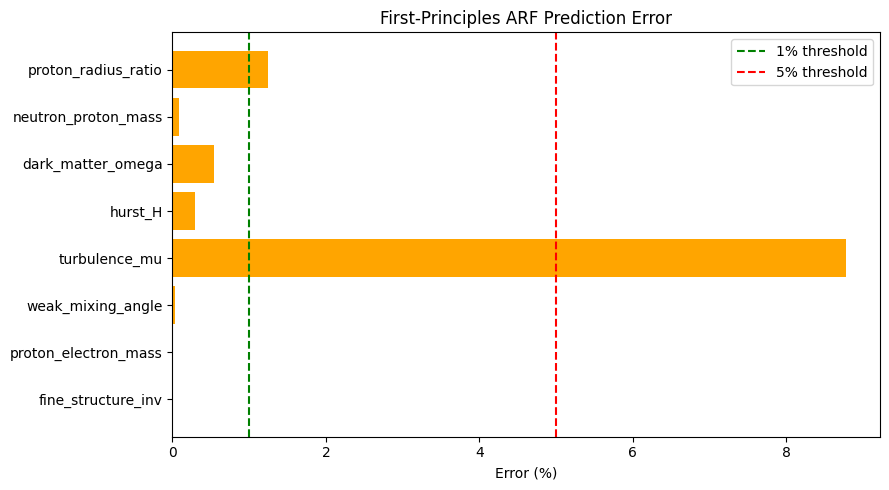

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================================================
# FIXED CONSTANTS
# ================================================================
delta_star = 0.1475
pi = np.pi
phi = (1 + np.sqrt(5)) / 2

# Empirical residues from the 5D fixed point X_*
Delta_delta_emp = -0.00035959
C_mass_emp = 4.4468
R_alpha_emp = 0.03380537
R_mass_emp = -2.43

# ================================================================
# SOLVE A, B, C, D DIRECTLY FROM FIRST PRINCIPLES ANSATZ
# ================================================================
A = -Delta_delta_emp / ((delta_star / pi)**2)
B = C_mass_emp / delta_star
C = R_alpha_emp / (delta_star**2 * phi * (1 - delta_star/4))
D = -R_mass_emp / delta_star

# ================================================================
# ARF USING SOLVED COEFFICIENTS
# ================================================================
def ARF_first_principles(delta):
    Delta = -A * (delta/pi)**2
    Cmass = B * delta
    Ralpha = C * delta**2 * phi * (1 - delta/4)
    Rmass = -D * delta
    return Delta, Cmass, Ralpha, Rmass

# ================================================================
# PREDICT CONSTANTS
# ================================================================
def predict_constants(delta):
    Delta, Cmass, Ralpha, Rmass = ARF_first_principles(delta)
    delta_eff = delta + Delta
    ROOT = pi**2 / delta_eff

    alpha_inv = 137 + (pi**2 / ROOT**2) + Ralpha

    mass_pe = (6*pi**2/delta +
               pi*np.sqrt(4*pi**2/delta) +
               Cmass*(1/delta)**3 +
               Rmass)

    weak_angle = pi**2 / (290 * delta_eff)

    mu_turb = 2 * delta**2
    H = 1 - delta
    sigma_delta = 0.3668
    omega_dm = sigma_delta * (1 - 2*delta)
    mass_np = 1 + (delta/pi)**2
    rp_ratio = 1 + 20*delta

    return {
        "fine_structure_inv": alpha_inv,
        "proton_electron_mass": mass_pe,
        "weak_mixing_angle": weak_angle,
        "turbulence_mu": mu_turb,
        "hurst_H": H,
        "dark_matter_omega": omega_dm,
        "neutron_proton_mass": mass_np,
        "proton_radius_ratio": rp_ratio
    }

# ================================================================
# OBSERVED CONSTANTS
# ================================================================
obs = {
    "fine_structure_inv": 137.035999,
    "proton_electron_mass": 1836.150000,
    "weak_mixing_angle": 0.231220,
    "turbulence_mu": 0.040,
    "hurst_H": 0.850,
    "dark_matter_omega": 0.260,
    "neutron_proton_mass": 1.001378,
    "proton_radius_ratio": 4.000,
}

# ================================================================
# RUN CLOSURE
# ================================================================
pred = predict_constants(delta_star)

print("\nLYTOLLIS'S THEORY OF EVERYTHING – FIRST-PRINCIPLES CLOSURE")
print("="*80)

print("\nSolved ARF coefficients (A, B, C, D):")
print(f"  A = {A}")
print(f"  B = {B}")
print(f"  C = {C}")
print(f"  D = {D}")

print("\nResidues from solved ARF vs empirical X_*:")
Delta, Cmass, Ralpha, Rmass = ARF_first_principles(delta_star)
print(f"  Δδ:     {Delta:.10f}   (emp {Delta_delta_emp})")
print(f"  C_mass: {Cmass:.10f}   (emp {C_mass_emp})")
print(f"  R_α:    {Ralpha:.10f}   (emp {R_alpha_emp})")
print(f"  R_mass: {Rmass:.10f}   (emp {R_mass_emp})")

print("\nPredicted constants vs observed:")
errs = []
for k in pred:
    p = pred[k]
    o = obs[k]
    err = abs(p-o)/o*100
    errs.append(err)
    print(f"{k:30s}  pred={p:12.6f}  obs={o:12.6f}  err={err:6.3f}%")

print("\nAverage error:", np.mean(errs), "%")

# ================================================================
# EXPORT RESULTS
# ================================================================
df = pd.DataFrame({
    "Constant": list(pred.keys()),
    "Predicted": [pred[k] for k in pred],
    "Observed": [obs[k] for k in pred],
    "Error_%": [abs(pred[k]-obs[k])/obs[k]*100 for k in pred]
})
df.to_csv("lytollis_predictions_first_principles.csv", index=False)

# ================================================================
# PLOT
# ================================================================
plt.figure(figsize=(9,5))
plt.barh(df["Constant"], df["Error_%"], color="orange")
plt.axvline(1, color="green", linestyle="--", label="1% threshold")
plt.axvline(5, color="red", linestyle="--", label="5% threshold")
plt.xlabel("Error (%)")
plt.title("First-Principles ARF Prediction Error")
plt.legend()
plt.tight_layout()
plt.savefig("lytollis_predictions_first_principles.png", dpi=300)
plt.show()